In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df = pd.read_csv("students.csv")
df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [41]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)

Shape: (15, 9)

Data Types:
 name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


In [42]:
df.describe()

,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,65.000000,66.733333,66.200000,63.400000,74.800000,75.800000,2.893333,0.600000
std,20.060622,18.967893,17.773174,16.936014,16.657045,14.722189,1.658944,0.507093
min,30.000000,35.000000,40.000000,28.000000,45.000000,50.000000,0.500000,0.000000
25%,51.500000,53.500000,49.000000,53.500000,61.000000,63.500000,1.650000,0.000000
50%,65.000000,65.000000,70.000000,62.000000,75.000000,78.000000,2.800000,1.000000
75%,80.000000,77.000000,81.000000,73.500000,89.000000,86.500000,3.900000,1.000000
max,95.000000,98.000000,91.000000,92.000000,97.000000,98.000000,6.000000,1.000000


In [43]:
df['passed'].value_counts()

passed
1    9
0    6
Name: count, dtype: int64

In [44]:
subjects = ['math', 'science', 'english', 'history', 'pe']

print("Passing Students:\n", df[df['passed']==1][subjects].mean())
print("\nFailing Students:\n", df[df['passed']==0][subjects].mean())

Passing Students:
 math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

Failing Students:
 math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


In [45]:
df['average'] = df[subjects].mean(axis=1)
top = df.loc[df['average'].idxmax()]

print(top['name'], top['average'])

Diana 94.0


In [46]:
#---------- FOR THE PART 2 ----------#
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

df[['name', 'avg_score']].head()

,name,avg_score
0,Alice,86.2
1,Bob,51.0
2,Charlie,76.2
3,Diana,94.0
4,Eve,46.0


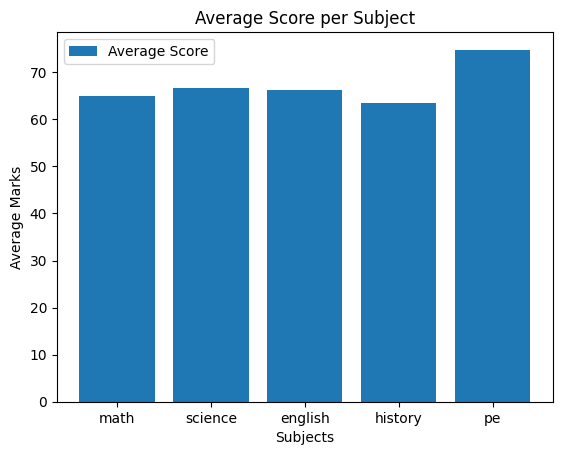

In [47]:
# 1. BAR CHART:
avg_marks = df[subject_cols].mean()

plt.figure()
plt.bar(avg_marks.index, avg_marks.values, label="Average Score")

plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Marks")
plt.legend()

plt.savefig("plot1_bar.png")
plt.show()

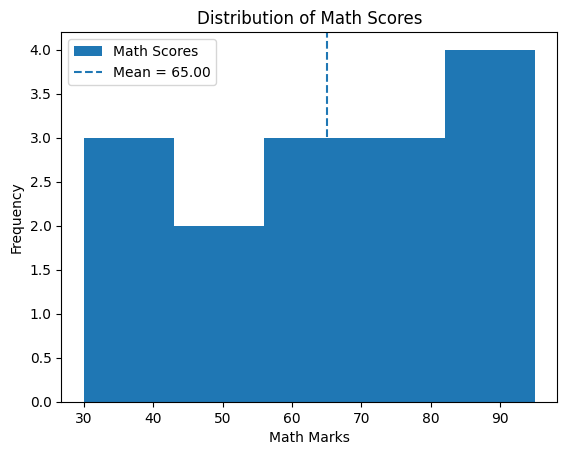

In [48]:
# 2. HISTOGRAM:
plt.figure()
plt.hist(df['math'], bins=5, label="Math Scores")

mean_math = df['math'].mean()

plt.axvline(mean_math, linestyle='dashed', label=f"Mean = {mean_math:.2f}")

plt.title("Distribution of Math Scores")
plt.xlabel("Math Marks")
plt.ylabel("Frequency")
plt.legend()

plt.savefig("plot2_hist.png")
plt.show()

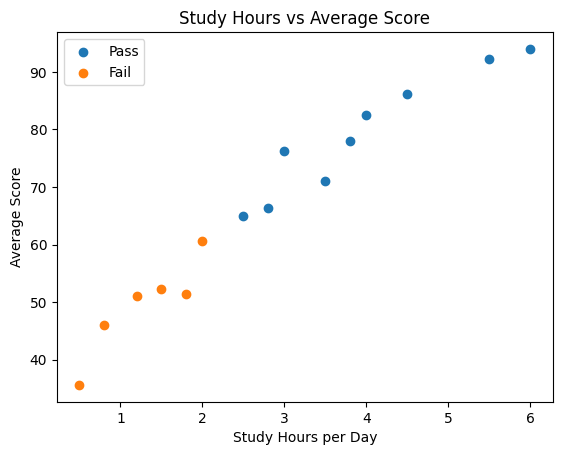

In [49]:
# 3. SCATTER PLOT:
plt.figure()

# Passing students
pass_data = df[df['passed'] == 1]
plt.scatter(pass_data['study_hours_per_day'], pass_data['avg_score'], label="Pass")

# Failing students
fail_data = df[df['passed'] == 0]
plt.scatter(fail_data['study_hours_per_day'], fail_data['avg_score'], label="Fail")

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()

C:\Users\RACHIT\AppData\Local\Temp\ipykernel_5884\2076581599.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


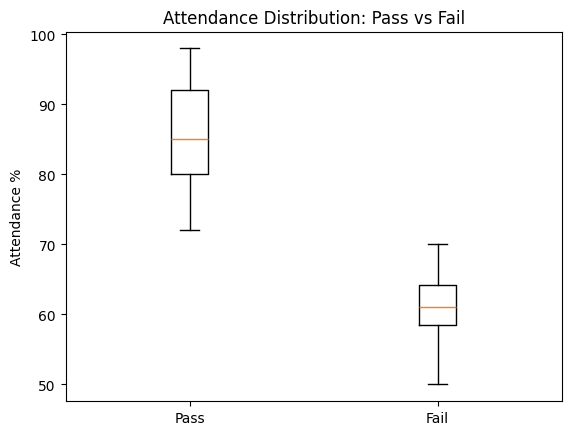

In [51]:
# 4. BOX PLOT:
pass_attendance = df[df['passed']==1]['attendance_pct'].tolist()
fail_attendance = df[df['passed']==0]['attendance_pct'].tolist()

plt.figure()
plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])

plt.title("Attendance Distribution: Pass vs Fail")
plt.ylabel("Attendance %")

plt.savefig("plot4_box.png")
plt.show()

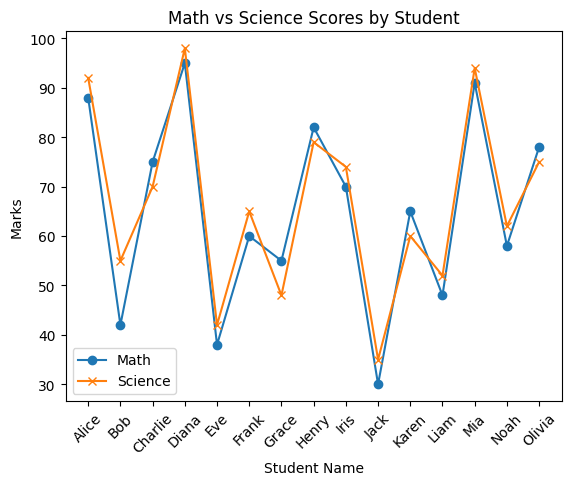

In [53]:
# 5. LINE PLOT:
plt.figure()

plt.plot(df['name'], df['math'], marker='o', label="Math")
plt.plot(df['name'], df['science'], marker='x', label="Science")

plt.xticks(rotation=45)

plt.title("Math vs Science Scores by Student")
plt.xlabel("Student Name")
plt.ylabel("Marks")
plt.legend()

plt.savefig("plot5_line.png")
plt.show()

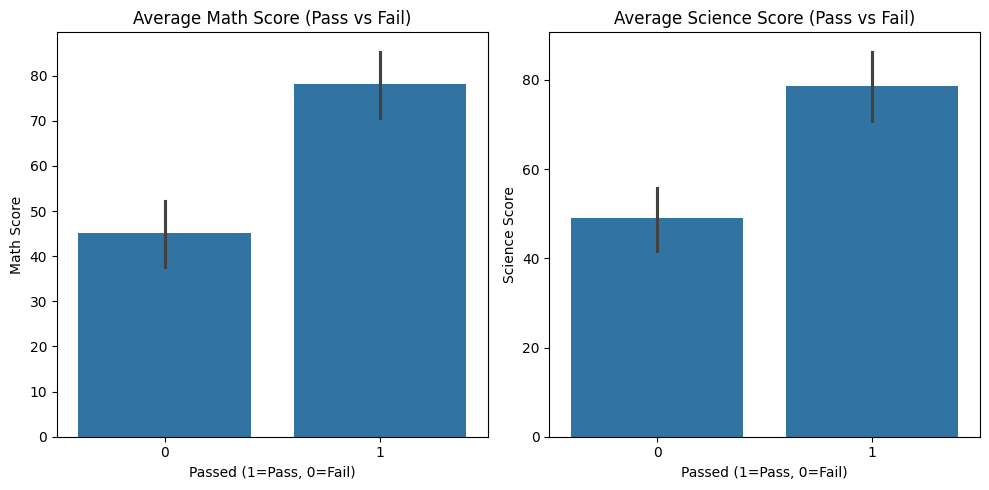

In [55]:
## ----------TASK 3 ---------- ##

# 1. SEABORN BAR PLOT 
plt.figure(figsize=(10,5))

# Subplot 1 → Math
ax1 = plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Average Math Score (Pass vs Fail)")
ax1.set_xlabel("Passed (1=Pass, 0=Fail)")
ax1.set_ylabel("Math Score")

# Subplot 2 → Science
ax2 = plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Average Science Score (Pass vs Fail)")
ax2.set_xlabel("Passed (1=Pass, 0=Fail)")
ax2.set_ylabel("Science Score")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()

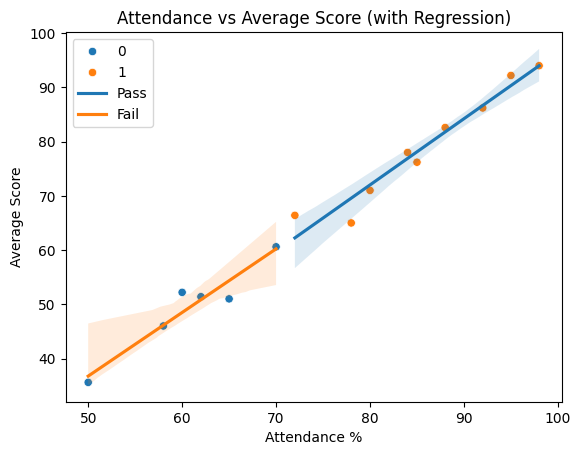

In [56]:
# 2. SEABORN SCATER PLOT:
plt.figure()

# Scatter plot
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

# Regression for Pass
sns.regplot(data=df[df['passed']==1],
            x='attendance_pct', y='avg_score',
            scatter=False, label='Pass')

# Regression for Fail
sns.regplot(data=df[df['passed']==0],
            x='attendance_pct', y='avg_score',
            scatter=False, label='Fail')

plt.title("Attendance vs Average Score (with Regression)")
plt.xlabel("Attendance %")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot7_seaborn_scatter.png")
plt.show()

In [57]:
## BELOW ARE MY EXPERINCE WITH REGARDS OF USING SEABORN AND MATLOTLIB:-
# Seaborn was easier to use compared to Matplotlib for statistical plots like barplots and regression.
# It automatically handles grouping and styling, reducing the amount of code required.
# Matplotlib gives more control but requires more manual work for similar visualizations.

In [58]:
## ----------TASK 4 ---------- ##
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

In [59]:
# Features (DO NOT include name)
X = df[['math','science','english','history','pe',
        'attendance_pct','study_hours_per_day']]

# Target
y = df['passed']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [60]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Training accuracy
train_pred = model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, train_pred)

print("Training Accuracy:", train_acc)

Training Accuracy: 1.0


In [61]:
# Predictions
y_pred = model.predict(X_test_scaled)

# Test accuracy
test_acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_acc)

Test Accuracy: 1.0


In [62]:
# Get names using index
test_names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(test_names, y_test, y_pred):
    result = "✅ Correct" if actual == pred else "❌ Wrong"
    print(f"{name} | Actual: {actual} | Predicted: {pred} → {result}")

Jack | Actual: 0 | Predicted: 0 → ✅ Correct
Liam | Actual: 0 | Predicted: 0 → ✅ Correct
Alice | Actual: 1 | Predicted: 1 → ✅ Correct
